# Causal AI Fairness — Example 4

In this notebook, we reproduce **Example 5** from the paper *Automatic Causal Fairness Analysis with LLM-Generated Reporting*.  
The goal is to demonstrate a compact end-to-end causal fairness analysis workflow.

In particular, we will:

- load a processed dataset
- define a Structural Fairness Model (SFM)
- fit a discrete Bayesian network
- compute observational and causal fairness effects
- inspect the distributions of the effects in the case of a continuous Y variable

## 1. Imports and repository setup

In [3]:
from pathlib import Path
import sys

import pandas as pd
from pgmpy.estimators import BayesianEstimator

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent

if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

from src.effects import DE, IE, SE, TE, TV, effect_distribution, utility_weighted_effect
from src.graph import build_sfm
from src.model import fit_discrete_bayesian_model
from src.visualisation.graph import visualize_sfm
from src.llm import (
    prepare_llm_payload_general,
    payload_to_json,
    summarize_with_llm_combined,
)

REPO_ROOT

PosixPath('/Users/eric.rossetto/Documents/Code/fairness/causal-ai-fairness')

In [4]:
from openai import OpenAI
from dotenv import load_dotenv
import os

load_dotenv(override=True)  # loads OPENAI_API_KEY from .env

if os.getenv("OPENAI_API_KEY") is None:
    raise RuntimeError("OPENAI_API_KEY not found. ")


client = OpenAI()

## 2. Load and prepare data

We reuse the processed Adult dataset and consider `education` as an ordered categorical variable in the discrete Bayesian network.

In [5]:
data_path = REPO_ROOT / "data" / "processed" / "adult.csv"
df = pd.read_csv(data_path)
selected_columns = [
    "hours-per-week",
    "occupation",
    "S2_gender",
]

df[selected_columns].head()


,hours-per-week,occupation,S2_gender
0,40,Machine-op-inspct,Male
1,50,Farming-fishing,Male
2,40,Protective-serv,Male
3,40,Machine-op-inspct,Male
4,30,Other,Female


In [6]:
df["occupation"].dtype
df["occupation"] = df["occupation"].astype("category")
df["S2_gender"].dtype
df["S2_gender"] = df["S2_gender"].astype("category")


In [7]:
df[selected_columns].nunique().rename("cardinality")

hours-per-week    96
occupation        15
S2_gender          2
Name: cardinality, dtype: int64

## 3. Define the Structural Fairness Model

This graph encodes one sensitive attribute, one observed confounder, one mediator, and one outcome.

In [8]:
private_attr = "S2_gender"
outcome_attr = "hours-per-week"
confounders = []
mediators = ["occupation"]

sfm = build_sfm(
    sensitive_attr=private_attr,
    outcome_attr=outcome_attr,
    confounder_attrs=confounders,
    mediator_attrs=mediators,
)

sorted(sfm.edges())

[('S2_gender', 'hours-per-week'),
 ('S2_gender', 'occupation'),
 ('occupation', 'hours-per-week')]

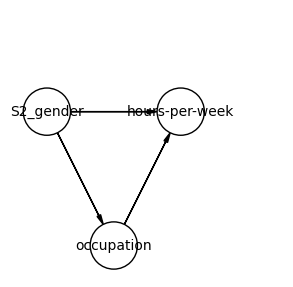

In [9]:
visualize_sfm(sfm)

## 4. Fit the Bayesian network

`fit_discrete_bayesian_model` keeps the SFM structure fixed and estimates the conditional distributions from the data.

In [10]:
bn = fit_discrete_bayesian_model(
    sfm=sfm,
    data=df[selected_columns],
    estimator_instance=(
        BayesianEstimator,
        {"prior_type": "dirichlet", "pseudo_counts": 1.0},
    ),
)

assert bn.check_model()
bn

2026-04-27 17:52:11.833 | DEBUG    | src.model:fit_discrete_bayesian_model:33 - Using estimator: <class 'pgmpy.estimators.BayesianEstimator.BayesianEstimator'> with parameters: {'prior_type': 'dirichlet', 'pseudo_counts': 1.0}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'hours-per-week': 'N', 'occupation': 'C', 'S2_gender': 'C'}


In [11]:
variable_metadata = pd.Series(
    {node: bn.get_cpds(node).state_names[node] for node in bn.nodes}, name="states"
)

## 5. Compute core fairness effects

We evaluate the probability of the y outcome when comparing `Female` to `Male`.

We first compute the pointwise effects for each exact outcome level y. Then we take the cumulative sum over ordered y. 

In the end, we look at a specific $Y\leq y$


In [12]:
ys = sorted(df[outcome_attr].unique())


In [13]:
x0 = "Female"
x1 = "Male"
ys = sorted(df[outcome_attr].unique())

effects = []

for y in ys:
    target = (outcome_attr, y)

    effects.append(
        {
            "y": y,
            "TV": TV(bn, target, private_attr, x0, x1),
            "TE": TE(bn, target, private_attr, x0, x1),
            "NDE": DE(bn, target, private_attr, x0, x1),
            "NIE": IE(bn, target, private_attr, x1, x0),
        }
    )


effects = pd.DataFrame(effects).sort_values("y").reset_index(drop=True)

effects.round(4)

effects_cum = effects.copy()
cols = ["TV", "TE", "NDE", "NIE"]
effects_cum[cols] = effects_cum[cols].cumsum()

cont_results = effects_cum.round(4)

2026-04-27 17:52:13.405 | DEBUG    | src.effects:total_variation:248 - Computing total variation for target=('hours-per-week', np.int64(1)), private_baseline=Female, private_mod=Male
2026-04-27 17:52:13.410 | DEBUG    | src.effects:total_variation:248 - Computing total variation for target=('hours-per-week', np.int64(2)), private_baseline=Female, private_mod=Male
2026-04-27 17:52:13.413 | DEBUG    | src.effects:total_variation:248 - Computing total variation for target=('hours-per-week', np.int64(3)), private_baseline=Female, private_mod=Male
2026-04-27 17:52:13.417 | DEBUG    | src.effects:total_variation:248 - Computing total variation for target=('hours-per-week', np.int64(4)), private_baseline=Female, private_mod=Male
2026-04-27 17:52:13.420 | DEBUG    | src.effects:total_variation:248 - Computing total variation for target=('hours-per-week', np.int64(5)), private_baseline=Female, private_mod=Male
2026-04-27 17:52:13.422 | DEBUG    | src.effects:total_variation:248 - Computing tota

In [14]:
print(effects_cum.round(4).to_csv(sep="\t", index=False))

y	TV	TE	NDE	NIE
1	-0.0006	-0.0006	-0.0004	0.0002
2	-0.0011	-0.0011	-0.0004	0.0007
3	-0.0022	-0.0022	-0.0011	0.0012
4	-0.0042	-0.0042	-0.0026	0.0016
5	-0.0063	-0.0063	-0.0041	0.0022
6	-0.008	-0.008	-0.0051	0.0029
7	-0.009	-0.009	-0.0057	0.0033
8	-0.0135	-0.0135	-0.009	0.0045
9	-0.0143	-0.0143	-0.0092	0.005
10	-0.0197	-0.0197	-0.0125	0.0072
11	-0.0203	-0.0203	-0.0129	0.0074
12	-0.0254	-0.0254	-0.0165	0.0089
13	-0.0261	-0.0261	-0.0169	0.0092
14	-0.0274	-0.0274	-0.0175	0.0099
15	-0.0409	-0.0409	-0.0271	0.0138
16	-0.047	-0.047	-0.0322	0.0147
17	-0.0482	-0.0482	-0.0333	0.0149
18	-0.0504	-0.0504	-0.0346	0.0158
19	-0.0515	-0.0515	-0.0356	0.016
20	-0.0837	-0.0837	-0.0581	0.0256
21	-0.0851	-0.0851	-0.0591	0.0259
22	-0.0862	-0.0862	-0.0599	0.0263
23	-0.0876	-0.0876	-0.0611	0.0265
24	-0.094	-0.094	-0.0657	0.0283
25	-0.1111	-0.1111	-0.0783	0.0328
26	-0.1119	-0.1119	-0.0786	0.0332
27	-0.1131	-0.1131	-0.0796	0.0336
28	-0.1169	-0.1169	-0.0827	0.0342
29	-0.1177	-0.1177	-0.0833	0.0344
30	-0.1368	-0.1368

In [15]:
y_val = 40

results = effects_cum[effects_cum["y"] == y_val].assign(
    threshold=lambda d: "<=" + d["y"].astype(str)
)[["threshold", "TV", "TE", "NDE", "NIE"]]

results


,threshold,TV,TE,NDE,NIE
39,<=40,-0.178346,-0.178346,-0.140943,0.037403


## 6. Verify the decomposition identity

The decomposition tests in the suite verify the identity

$TV(x_0, x_1, y) = TE(x_0, x_1, y) + (SE(x_1, y) - SE(x_0, y))$.

Checking it directly in the notebook is a useful sanity test for a fitted model.

In this case we have no confounders, TV=TE. 

The decomposition tests TE in the suite verify the identity

$TE(x_0, x_1, y) = NDE(x_0, x_1, y) - NIE(x_1,x_0,y)$.

In [16]:
decomposition_check_TE = pd.Series(
    {
        "TE": results["TE"].iloc[0],
        "NDE - NIE": (results["NDE"] - results["NIE"]).iloc[0],
    },
)

decomposition_check_TE.round(10)

TE          -0.178346
NDE - NIE   -0.178346
dtype: float64

## 7. LLM report

In [17]:
state_names = {
    node: bn.get_cpds(node).state_names[node]
    for node in bn.nodes
    if bn.get_cpds(node) is not None
}

In [18]:
payload = prepare_llm_payload_general(
    dataset_name="Adult Dataset",
    X=private_attr,
    Y=outcome_attr,
    W=mediators,
    Z=confounders,
    x0=x0,
    x1=x1,
    y_target=y_val,
    results=results.round(6),
    variable_metadata=variable_metadata,
    state_names=state_names,
    cont_results=cont_results,
    graph_edges=sorted(sfm.edges()),
    checks={
        "te_decomposition": decomposition_check_TE.round(10).to_dict(),
    },
)

In [19]:
payload_json = payload_to_json(payload)
payload_json

'{\n  "dataset": "Adult Dataset",\n  "causal_query": {\n    "X": "S2_gender",\n    "Y": "hours-per-week",\n    "W": [\n      "occupation"\n    ],\n    "Z": [],\n    "x0": "Female",\n    "x1": "Male",\n    "y_target": 40\n  },\n  "variable_metadata": {\n    "S2_gender": [\n      "Female",\n      "Male"\n    ],\n    "hours-per-week": [\n      "1",\n      "2",\n      "3",\n      "4",\n      "5",\n      "6",\n      "7",\n      "8",\n      "9",\n      "10",\n      "11",\n      "12",\n      "13",\n      "14",\n      "15",\n      "16",\n      "17",\n      "18",\n      "19",\n      "20",\n      "21",\n      "22",\n      "23",\n      "24",\n      "25",\n      "26",\n      "27",\n      "28",\n      "29",\n      "30",\n      "31",\n      "32",\n      "33",\n      "34",\n      "35",\n      "36",\n      "37",\n      "38",\n      "39",\n      "40",\n      "41",\n      "42",\n      "43",\n      "44",\n      "45",\n      "46",\n      "47",\n      "48",\n      "49",\n      "50",\n      "51",\n      "52

In [20]:
text, latex_doc, token_usage = summarize_with_llm_combined(payload_json, client)

INFO:httpx:HTTP Request: POST https://api.openai.com/v1/responses "HTTP/1.1 200 OK"


In [21]:
print(latex_doc)

\documentclass{article}
\usepackage{geometry}
\geometry{margin=1in}
\usepackage{amsmath}
\begin{document}
Title: "Fairness Decomposition Report"

\subsection*{Overview of the Fairness Analysis}
This analysis examines fairness in the Adult Dataset for the outcome hours-per-week ($Y$), comparing S2\_gender groups: $x_0$ Female vs $x_1$ Male, and decomposes the observed difference into direct, indirect (via occupation), and spurious components across thresholds. Across the provided thresholds (y values shown from $1$ to $99$), the total variation ($TV$) and total effect ($TE$) vary with threshold and are non-monotonic: they are very small near $y = 1$ ($TV \approx -0.0006$), grow in negative magnitude to a peak around $y = 5$ ($TV \approx -0.0063$), and then decline toward zero at high $y$ (e.g., $TV \approx -0.0007$ at $y \approx 95$); the direct effect ($NDE$) is negative and shows the largest changes (e.g., $NDE \approx -0.0004$ at $y = 1$ to $NDE \approx -0.0041$ at $y = 5$) while the